In [1]:
import pandas as pd
import numpy as np
# Load customer features
df = pd.read_csv("customer_features.csv")
# Create RFM dataframe
rfm = df[[
    "customer_unique_id",
    "recency",
    "total_orders",
    "total_spent"
]].copy()
rfm.rename(columns={
    "recency":"Recency",
    "total_orders":"Frequency",
    "total_spent":"Monetary"
}, inplace=True)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,df3bcbcb88d40ad1996ad1325fe8f481,124,1,160.28
1,58704dbb44acbec0448a215ac2871320,379,1,70.72
2,e06358b52b33afa8edfe5a0664cfe9c5,240,1,60.10
3,ee66c72bc9c41ae9de8260314b8088f4,119,1,247.36
4,c2e79de2c0a7751e26564a3917f9e86d,504,1,115.44


In [2]:
rfm.isnull().sum()

customer_unique_id    0
Recency               0
Frequency             0
Monetary              1
dtype: int64

In [3]:
rfm = rfm.dropna()

In [4]:
#Recency Score
rfm["R"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1],
    duplicates="drop"
).astype(int)

In [5]:
#Frequency Score
rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [6]:
#Monetary Score
rfm["M"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [7]:
#Total RFM Score
rfm["RFM_Score"] = (
    rfm["R"] +
    rfm["F"] +
    rfm["M"]
)
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R,F,M,RFM_Score
0,df3bcbcb88d40ad1996ad1325fe8f481,124,1,160.28,5,1,4,10
1,58704dbb44acbec0448a215ac2871320,379,1,70.72,2,1,2,5
2,e06358b52b33afa8edfe5a0664cfe9c5,240,1,60.10,3,1,2,6
3,ee66c72bc9c41ae9de8260314b8088f4,119,1,247.36,5,1,5,11
4,c2e79de2c0a7751e26564a3917f9e86d,504,1,115.44,1,1,3,5


In [8]:
#Segment Customers
def segment(score):
    if score >= 13:
        return "Champions"
    elif score >= 11:
        return "Loyal Customers"
    elif score >= 9:
        return "Potential Loyalists"
    elif score >= 7:
        return "Promising"
    elif score >= 5:
        return "Needs Attention"
    else:
        return "At Risk"
rfm["Segment"] = rfm["RFM_Score"].apply(segment)

In [9]:
#Segment Distribution
rfm["Segment"].value_counts()

Segment
Potential Loyalists    27732
Promising              25031
Loyal Customers        19155
Needs Attention        12740
Champions               8205
At Risk                 3232
Name: count, dtype: int64

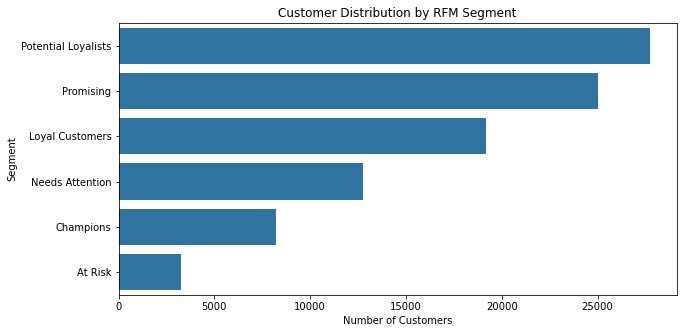

In [10]:
#Visualize Segments
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.countplot(
    data=rfm,
    y="Segment",
    order=rfm["Segment"].value_counts().index
)
plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.show()

In [11]:
#Segment Summary
rfm.groupby("Segment").agg(
    Customers=("customer_unique_id","count"),
    Avg_Recency=("Recency","mean"),
    Avg_Frequency=("Frequency","mean"),
    Avg_Monetary=("Monetary","mean")
).round(2)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,3232,490.28,1.00,47.22
Champions,8205,142.92,1.21,336.45
Loyal Customers,19155,208.12,1.06,238.95
Needs Attention,12740,404.99,1.00,68.17
Potential Loyalists,27732,265.76,1.01,164.58
Promising,25031,336.06,1.00,117.26


In [12]:
#Customer Lifetime Value+ RFM
clv = df.merge(
    rfm,
    on="customer_unique_id",
    how="left"
)

In [13]:
clv = df.merge(
    rfm,
    on="customer_unique_id",
    how="left"
)

In [14]:
#Historical CLV
clv["Historical_CLV"] = clv["total_spent"]
clv[["customer_unique_id","Historical_CLV"]].head()

,customer_unique_id,Historical_CLV
0,df3bcbcb88d40ad1996ad1325fe8f481,160.28
1,58704dbb44acbec0448a215ac2871320,70.72
2,e06358b52b33afa8edfe5a0664cfe9c5,60.10
3,ee66c72bc9c41ae9de8260314b8088f4,247.36
4,c2e79de2c0a7751e26564a3917f9e86d,115.44


In [15]:
#Summary Statistics
clv["Historical_CLV"].describe()

count    96095.000000
mean       165.024963
std        229.830686
min          0.000000
25%         62.330000
50%        106.900000
75%        181.860000
max      13664.080000
Name: Historical_CLV, dtype: float64

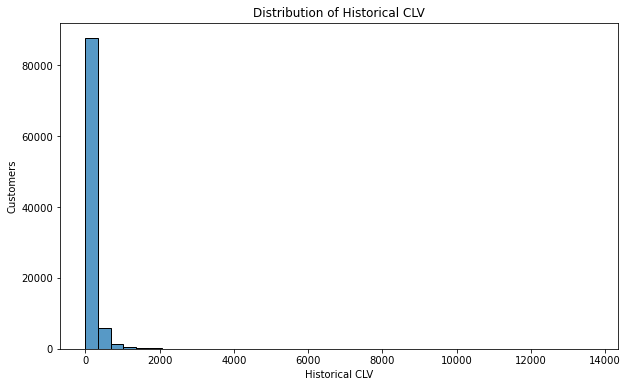

In [16]:
#Distribution of CLV
plt.figure(figsize=(10,6))
sns.histplot(
    clv["Historical_CLV"],
    bins=40,
    kde=False
)
plt.title("Distribution of Historical CLV")
plt.xlabel("Historical CLV")
plt.ylabel("Customers")
plt.show()

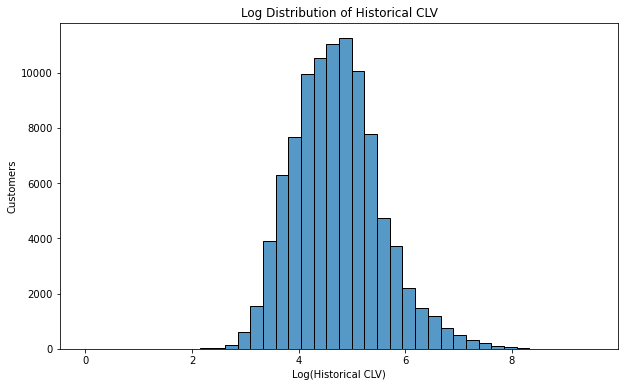

In [17]:
#Log Distribution
plt.figure(figsize=(10,6))
sns.histplot(
    np.log1p(clv["Historical_CLV"]),
    bins=40,
    kde=False
)
plt.title("Log Distribution of Historical CLV")
plt.xlabel("Log(Historical CLV)")
plt.ylabel("Customers")
plt.show()

In [18]:
#Create CLV Levels
clv["CLV_Level"] = pd.qcut(
    clv["Historical_CLV"],
    4,
    labels=[
        "Low",
        "Medium",
        "High",
        "VIP"
    ]
)

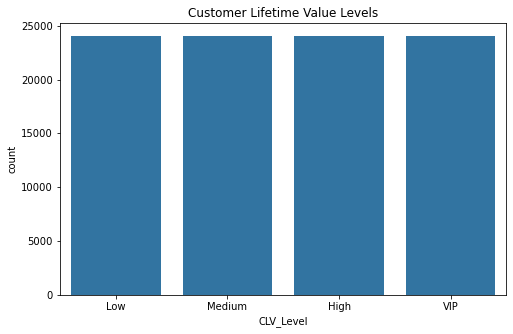

In [19]:
#CLV Distribution
plt.figure(figsize=(8,5))
sns.countplot(
    data=clv,
    x="CLV_Level",
    order=["Low","Medium","High","VIP"]
)
plt.title("Customer Lifetime Value Levels")
plt.show()

In [20]:
#Average CLV by RFM Segment
segment_clv = (
    clv
    .groupby("Segment")["Historical_CLV"]
    .mean()
    .sort_values(ascending=False)
)

segment_clv

Segment
Champions              336.454012
Loyal Customers        238.949224
Potential Loyalists    164.582181
Promising              117.259598
Needs Attention         68.168699
At Risk                 47.218131
Name: Historical_CLV, dtype: float64

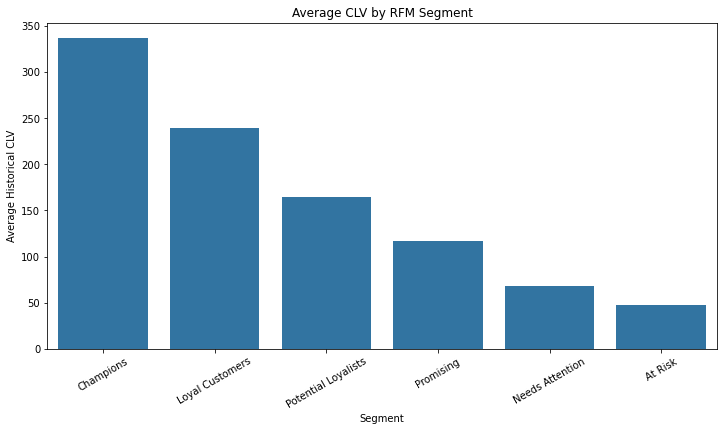

In [21]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=segment_clv.index,
    y=segment_clv.values
)
plt.xticks(rotation=30)
plt.title("Average CLV by RFM Segment")
plt.ylabel("Average Historical CLV")
plt.show()

In [22]:
#Revenue Contribution by Segment
segment_revenue = (
    clv
    .groupby("Segment")["Historical_CLV"]
    .sum()
    .sort_values(ascending=False)
)
segment_revenue

Segment
Loyal Customers        4577072.38
Potential Loyalists    4564193.04
Promising              2935125.01
Champions              2760605.17
Needs Attention         868469.22
At Risk                 152609.00
Name: Historical_CLV, dtype: float64

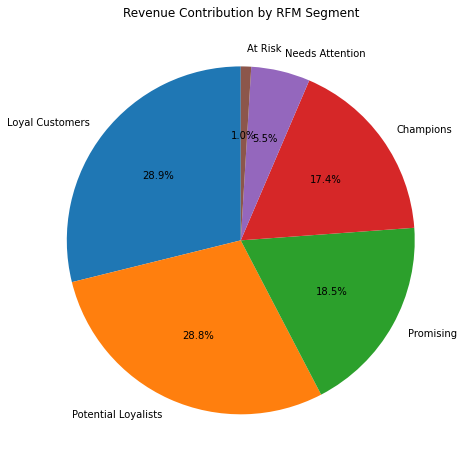

In [23]:
plt.figure(figsize=(8,8))
plt.pie(
    segment_revenue,
    labels=segment_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue Contribution by RFM Segment")
plt.show()

In [24]:
#Heatmap (RFM Segment vs CLV Level)
heat = pd.crosstab(
    clv["Segment"],
    clv["CLV_Level"]
)
heat

CLV_Level,Low,Medium,High,VIP
Segment,,,,
At Risk,2608,624,0,0
Champions,0,334,2151,5720
Loyal Customers,1190,3525,6162,8278
Needs Attention,6634,4250,1698,158
Potential Loyalists,5005,7391,8528,6808
Promising,8588,7916,5469,3058


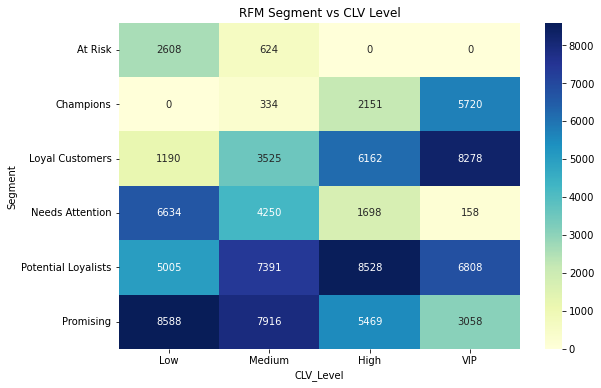

In [25]:
plt.figure(figsize=(9,6))
sns.heatmap(
    heat,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)
plt.title("RFM Segment vs CLV Level")
plt.show()

In [26]:
#Segment Summary
summary = (
    clv
    .groupby("Segment")
    .agg(
        Customers=("customer_unique_id","count"),
        Average_CLV=("Historical_CLV","mean"),
        Median_CLV=("Historical_CLV","median"),
        Average_Orders=("total_orders","mean"),
        Average_Order_Value=("average_order_value","mean"),
        Average_Review=("average_review","mean")
    )
    .round(2)
)
summary.sort_values(
    "Average_CLV",
    ascending=False
)

,Customers,Average_CLV,Median_CLV,Average_Orders,Average_Order_Value,Average_Review
Segment,,,,,,
Champions,8205,336.45,236.70,1.21,299.29,4.08
Loyal Customers,19155,238.95,163.69,1.06,230.35,4.07
Potential Loyalists,27732,164.58,116.83,1.01,163.78,4.07
Promising,25031,117.26,79.81,1.00,117.19,4.09
Needs Attention,12740,68.17,60.71,1.00,68.17,4.13
At Risk,3232,47.22,45.00,1.00,47.22,4.12


In [27]:
#Top 20 Customers
top20 = (
    clv
    .sort_values("Historical_CLV",ascending=False)
    .head(20)
)
top20[[
    "customer_unique_id",
    "Historical_CLV",
    "Segment",
    "total_orders",
    "average_review"
]]

,customer_unique_id,Historical_CLV,Segment,total_orders,average_review
91653,0a0a92112bd4c708ca5fde585afaa872,13664.08,Loyal Customers,1,1.0
12068,46450c74a0d8c5ca9395da1daac6c120,9553.02,Champions,3,1.0
24052,da122df9eeddfedc1dc1f5349a1a690c,7571.63,Loyal Customers,2,5.0
9005,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,Loyal Customers,1,1.0
13643,dc4802a71eae9be1dd28f5d788ceb526,6929.31,Promising,1,5.0
19171,459bef486812aa25204be022145caa62,6922.21,Loyal Customers,1,NaN
52022,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,Potential Loyalists,1,5.0
7511,4007669dec559734d6f53e029e360987,6081.54,Promising,1,1.0
18358,5d0a2980b292d049061542014e8960bf,4809.44,Loyal Customers,1,1.0
13999,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34,Promising,1,4.0


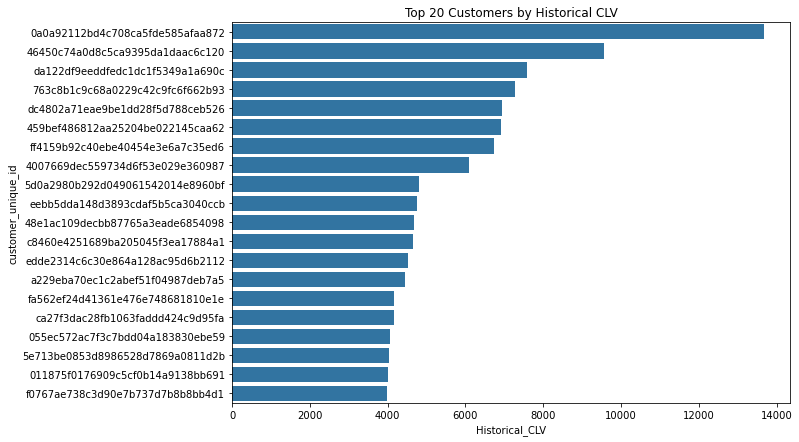

In [28]:
plt.figure(figsize=(10,7))
sns.barplot(
    data=top20,
    y="customer_unique_id",
    x="Historical_CLV"
)
plt.title("Top 20 Customers by Historical CLV")
plt.show()

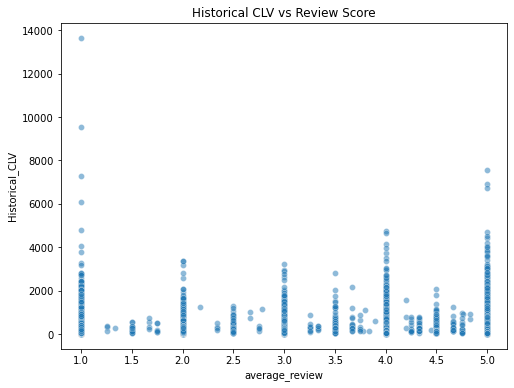

In [29]:
#CLV vs Review Score
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=clv,
    x="average_review",
    y="Historical_CLV",
    alpha=0.5
)
plt.title("Historical CLV vs Review Score")
plt.show()

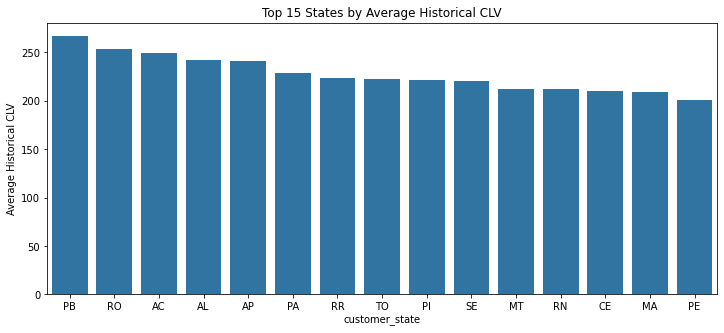

In [30]:
#CLV by State (Top 15)
state_clv = (
    clv
    .groupby("customer_state")["Historical_CLV"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(12,5))
sns.barplot(
    x=state_clv.index,
    y=state_clv.values
)
plt.title("Top 15 States by Average Historical CLV")
plt.ylabel("Average Historical CLV")
plt.show()

In [31]:
#High-Value Customers at Risk
at_risk = clv[
    (clv["CLV_Level"].isin(["High","VIP"])) &
    (clv["Segment"].isin([
        "Needs Attention",
        "At Risk"
    ]))
]
at_risk[[
    "customer_unique_id",
    "Historical_CLV",
    "Segment",
    "average_review",
    "total_orders"
]].head(20)

,customer_unique_id,Historical_CLV,Segment,average_review,total_orders
4,c2e79de2c0a7751e26564a3917f9e86d,115.44,Needs Attention,5.0,1
9,3f6faa55fa7e82f1245fff7e2118663b,170.58,Needs Attention,2.0,1
21,6e52008cfb7ee9d8382c2658aee5fcdb,114.11,Needs Attention,5.0,1
35,0372bebe6d71cf4dc807d24a53403d2e,133.47,Needs Attention,3.0,1
41,3bf91f240b1035e65c07bb19993e0853,126.57,Needs Attention,1.0,1
52,c14f30ca1ead07bd78cb1c97765cd97e,130.52,Needs Attention,4.0,1
58,c82aca6add83372a04a00a4446061a3f,107.87,Needs Attention,5.0,1
71,b3eb319b1c87a2f872261043e3d72494,167.29,Needs Attention,5.0,1
80,b6108acc674ae5c99e29adc1047d1049,199.64,Needs Attention,5.0,1
88,a0e1b13a3ee2d46c7de8d987ef47ec4b,139.59,Needs Attention,3.0,1


In [32]:
#Export Final Dataset
clv.to_csv("customer_clv_analysis.csv", index=False)

1) Historical CLV is highly right-skewed, indicating that a small proportion of customers contribute a large share of revenue.

2) Champions and Loyal Customers generally exhibit the highest average CLV and purchase frequency.

3) The VIP CLV group contributes a disproportionately large share of total revenue, reflecting a Pareto-like pattern. 

4) Some customers belong to Needs Attention or At Risk segments despite having high historical CLV, making them prime candidates for targeted retention campaigns.
5) Average CLV varies across states, suggesting opportunities for region-specific marketing and customer engagement strategies.

6) Comparing CLV with review scores and customer tenure helps identify whether satisfaction and long-term engagement are associated with higher customer value.